In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
plt.style.use('dark_background')

df = pd.read_csv('Salary Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [6]:
df = df.dropna()
df.drop_duplicates(inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324 entries, 0 to 371
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  324 non-null    float64
 1   Gender               324 non-null    object 
 2   Education Level      324 non-null    object 
 3   Job Title            324 non-null    object 
 4   Years of Experience  324 non-null    float64
 5   Salary               324 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [10]:
df[pd.isnull(df).any(axis=1)]
df.shape

(324, 6)

In [12]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [87]:
df.describe()

,Age,Years of Experience,Salary
count,324.000000,324.000000,324.000000
mean,37.382716,10.058642,99985.648148
std,7.185844,6.650470,48652.271440
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.500000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


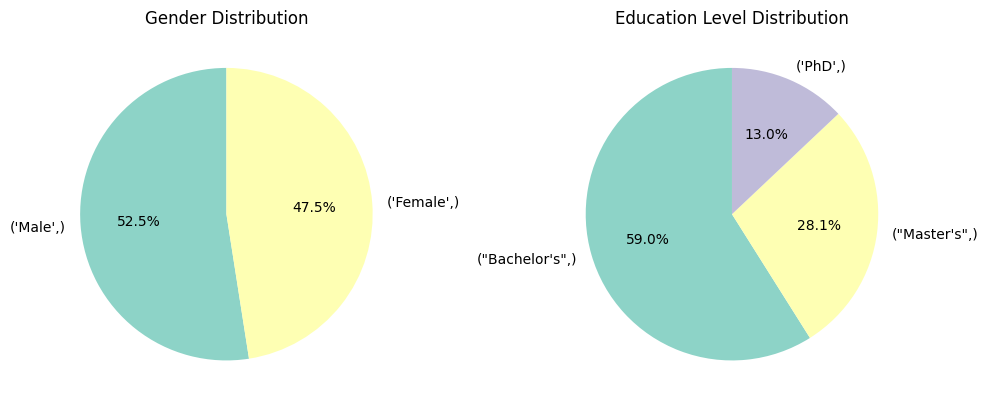

In [ ]:
#this code has been taken from Carson Cheng (https://www.kaggle.com/carsoncheng) and LaiLaiCoding (https://www.kaggle.com/lailaicoding)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.patch.set_facecolor('white')

gender_counts = df[['Gender']].value_counts()

ax1.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
        startangle=90, textprops={'color': 'black'})
ax1.set_title('Gender Distribution', color = 'black')


edu_counts = df[['Education Level']].value_counts()
ax2.pie(edu_counts.values, labels=edu_counts.index, autopct='%1.1f%%', 
        startangle=90, textprops={'color': 'black'})
ax2.set_title('Education Level Distribution', color = 'black')
plt.tight_layout()
plt.show()

Gender
Male      103472.647059
Female     96136.363636
Name: Salary, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

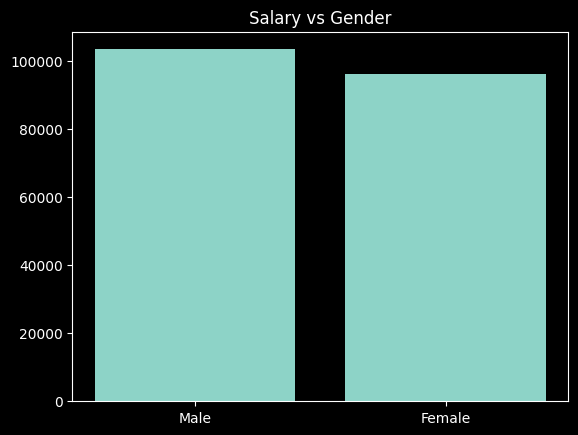

In [104]:
salary_by_gender = df.groupby("Gender")["Salary"].mean().sort_values(ascending=False)
print(salary_by_gender)
plt.bar(salary_by_gender.index,salary_by_gender.values)
plt.title("Salary vs Gender")
plt.show

In [ ]:
#now, testing hypothesis that education level plays crucial role in salary

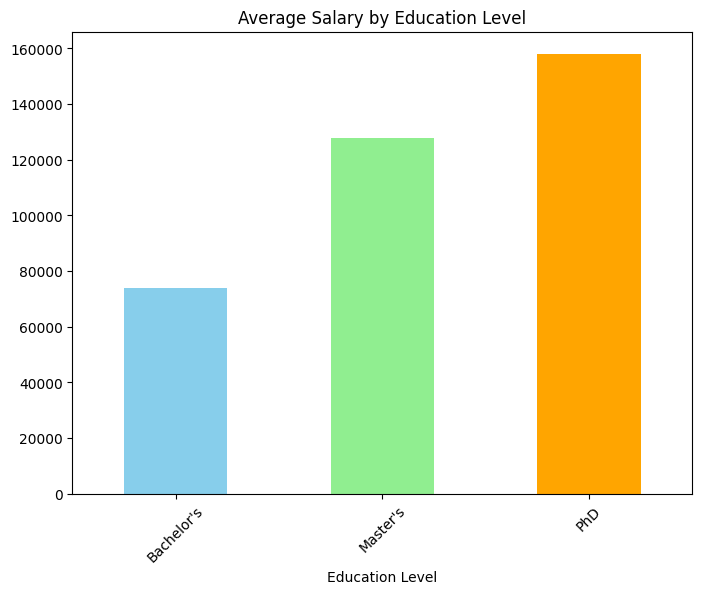

In [151]:

education_means = df.groupby("Education Level")['Salary'].mean()
plt.figure(figsize = (8,6))
education_means.plot(kind = 'bar', color = ['skyblue','lightgreen','orange'])
plt.title("Average Salary by Education Level")
plt.xticks(rotation = 45)
plt.show()

In [83]:
education_salary = df.groupby('Education Level')['Salary'].agg(['mean', 'median', 'count'])
print(education_salary.round(0))

# Calculate the difference
bachelors_avg = education_salary.loc["Bachelor's", 'mean']
masters_avg = education_salary.loc["Master's", 'mean']
phd_avg = education_salary.loc['PhD', 'mean']

print(f"\nSalary Increase:")
print(f"Bachelor's to Master's: ${int(masters_avg - bachelors_avg)} ({int(((masters_avg/bachelors_avg)-1)*100)}%)")
print(f"Master's to PhD: ${int(phd_avg - masters_avg)} ({int(((phd_avg/masters_avg)-1)*100)}%)")
print(f"Bachelor's to PhD: ${int(phd_avg - bachelors_avg)} ({int(((phd_avg/bachelors_avg)-1)*100)}%)")

                     mean    median  count
Education Level                           
Bachelor's        73902.0   60000.0    191
Master's         127912.0  120000.0     91
PhD              158095.0  157500.0     42

Salary Increase:
Bachelor's to Master's: $54009 (73%)
Master's to PhD: $30183 (23%)
Bachelor's to PhD: $84192 (113%)


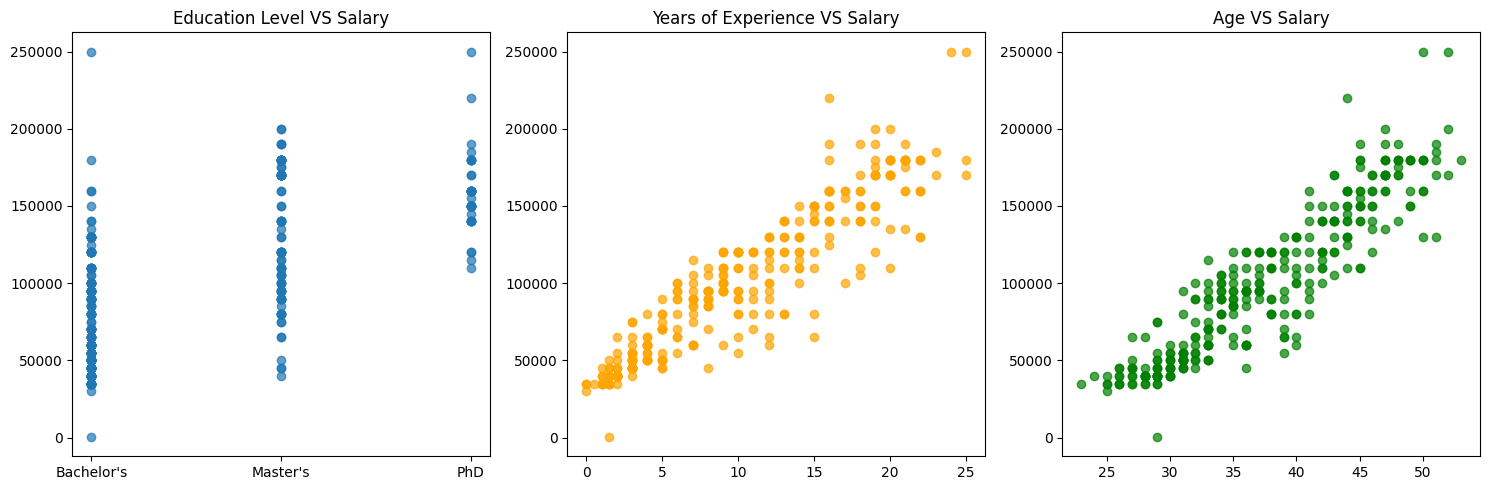

In [139]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(df['Education Level'], df['Salary'], alpha=0.7)
plt.title("Education Level VS Salary")

plt.subplot(1, 3, 2)
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.7, color='orange')
plt.title("Years of Experience VS Salary")

plt.subplot(1, 3, 3)
plt.scatter(df['Age'], df['Salary'], alpha=0.7, color='green')
plt.title("Age VS Salary")

plt.tight_layout()
plt.show()

In [132]:
def groupping(exp):
    if exp >= 0 and exp <= 5:
        return "0-5 years"
    elif exp > 5 and exp <= 10:
        return "6-10 years"
    elif exp > 10 and exp <= 15:
        return "11-15 years"
    elif exp > 15 and exp <= 20:
        return "16-20 years"
    else:
        return "20+" 

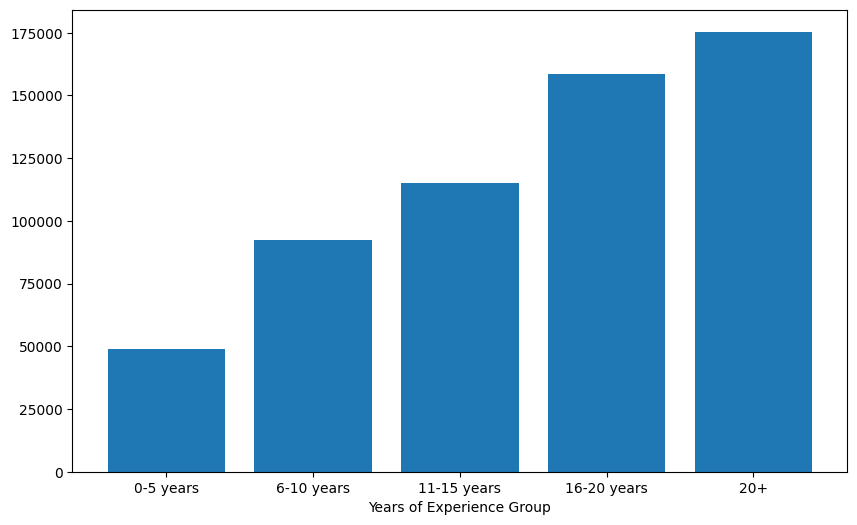

In [ ]:
df["Experience Group"] = df['Years of Experience'].apply(groupping)
experience_groups = df.groupby("Experience Group")['Salary'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.bar(experience_groups.index, experience_groups.values)
plt.xlabel('Years of Experience Group')
plt.show()

In [85]:
#testing hypothesis
df_encoded = df.copy()
df_encoded['Education_encoded'] = df_encoded['Education Level'].map({"Bachelor's": 0, "Master's": 1, 'PhD': 2})

correlation = df_encoded['Education_encoded'].corr(df_encoded['Salary'])
print(f"Correlation between Education Level and Salary: {correlation}")

if correlation > 0.8:
    print("✅Correlation is very strong positive")
elif correlation > 0.6:
    print("✅Correlation is strong positive")
else:
    print("❌ Correlation is not that strong")

Correlation between Education Level and Salary: 0.6618995280385022
✅Correlation is strong positive


In [99]:
print("Different correlations between features and salary: ")
print(f"Education Level: {round(df_encoded['Education_encoded'].corr(df_encoded['Salary']),2)}")
print(f"Years of Experience: {round(df['Years of Experience'].corr(df['Salary']),2)}")
print(f"Age: {round(df['Age'].corr(df['Salary']),2)}")


Different correlations between features and salary: 
Education Level: 0.66
Years of Experience: 0.92
Age: 0.92


<Figure size 800x600 with 0 Axes>

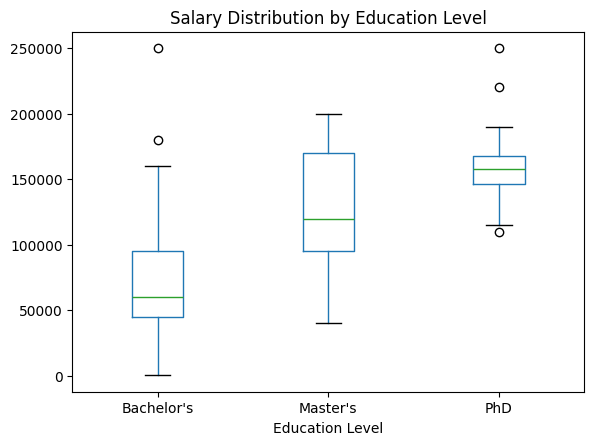

In [156]:
plt.figure(figsize=(8, 6))
df.boxplot(column='Salary', by='Education Level', grid=False)
plt.title('Salary Distribution by Education Level')
plt.suptitle('')  
plt.show()

In [ ]:
#Lets do a model

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['Salary'])
y = df[['Salary']]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(len(X_train),len(X_val),len(X_test))

207 52 65


In [18]:
for item in X_train.columns:
    print(f"{item} has {X_train[item].nunique()} values.")

Age has 31 values.
Gender has 2 values.
Education Level has 3 values.
Job Title has 138 values.
Years of Experience has 28 values.


In [ ]:
df['Years of Experience'].unique()

array([ 5. ,  3. , 15. ,  7. , 20. ,  2. , 12. ,  4. ,  1. , 10. , 18. ,
        6. , 14. , 16. ,  0. , 22. , 19. ,  9. , 13. , 11. , 25. , 21. ,
        8. , 17. , 23. , 24. ,  0.5,  1.5])

In [19]:
#correlation matrix
train_df_numerical = pd.concat([X_train[['Age', 'Years of Experience']], y_train], axis=1)
train_df_numerical.corr()

,Age,Years of Experience,Salary
Age,1.000000,0.979651,0.910218
Years of Experience,0.979651,1.000000,0.919103
Salary,0.910218,0.919103,1.000000


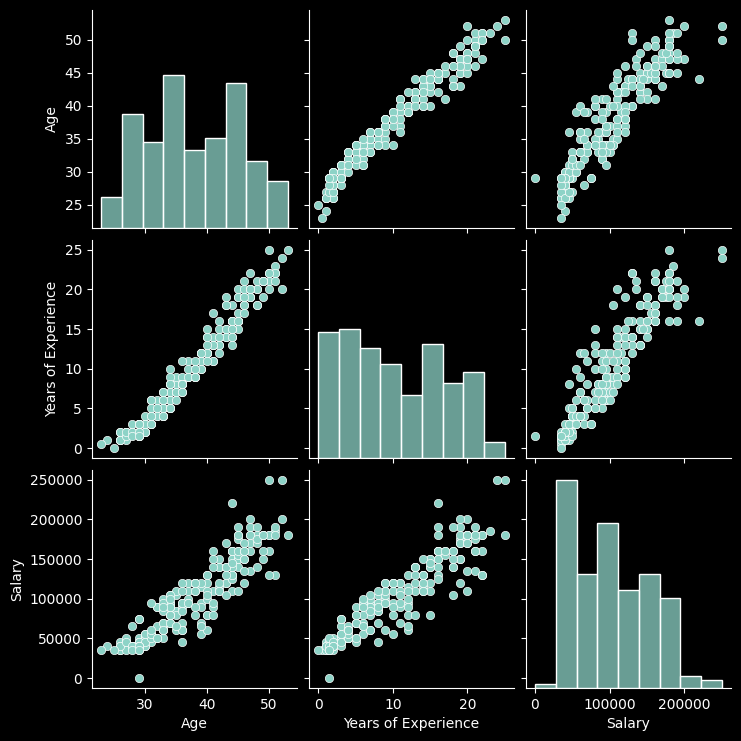

In [21]:
import seaborn as sns
sns.pairplot(train_df_numerical)

In [30]:
X_train.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience
80,36.0,Male,Bachelor's,Technical Recruiter,8.0
234,42.0,Female,PhD,Senior Marketing Manager,13.0
324,29.0,Female,Bachelor's,Junior Marketing Analyst,2.0
240,44.0,Female,PhD,Senior HR Manager,18.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0
333,33.0,Male,Bachelor's,Junior Product Manager,4.0
344,44.0,Female,PhD,Senior Data Engineer,16.0
237,45.0,Male,Master's,Senior Software Developer,16.0
50,51.0,Female,Bachelor's,Customer Service Manager,22.0
121,53.0,Male,Master's,Director of Marketing,25.0


In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_train['Gender_encoded'] = le.fit_transform(X_train['Gender'])
X_val['Gender_encoded'] = le.transform(X_val['Gender'])
X_test['Gender_encoded'] = le.transform(X_test['Gender'])
le = LabelEncoder()
X_train['Education_level_encoded'] = le.fit_transform(X_train['Education Level'])
X_val['Education_level_encoded'] = le.transform(X_val['Education Level'])
X_test['Education_level_encoded'] = le.transform(X_test['Education Level'])


In [36]:
X_train.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Gender_encoded,Education_level_encoded
80,36.0,Male,Bachelor's,Technical Recruiter,8.0,1,0
234,42.0,Female,PhD,Senior Marketing Manager,13.0,0,2
324,29.0,Female,Bachelor's,Junior Marketing Analyst,2.0,0,0
240,44.0,Female,PhD,Senior HR Manager,18.0,0,2
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,0,0


In [37]:
feature_cols = ['Age', 'Gender_encoded', 'Education_level_encoded', 'Years of Experience']
X_train = X_train[feature_cols]
X_val = X_val[feature_cols]
X_test = X_test[feature_cols]
X_train.head()

,Age,Gender_encoded,Education_level_encoded,Years of Experience
80,36.0,1,0,8.0
234,42.0,0,2,13.0
324,29.0,0,0,2.0
240,44.0,0,2,18.0
8,26.0,0,0,1.0


In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred)}")


print("\nPredictions")
for i in range(5):
    actual = float(y_test.iloc[i].values[0])
    predicted = float(y_pred[i])
    print(f"Actual: ${int(actual)} versus Predicted: ${int(predicted)}")

R² Score: 0.8922000384376029

Predictions
Actual: $100000 versus Predicted: $115614
Actual: $100000 versus Predicted: $124408
Actual: $50000 versus Predicted: $48441
Actual: $110000 versus Predicted: $128289
Actual: $105000 versus Predicted: $106959


C:\Users\Misha\AppData\Local\Temp\ipykernel_18152\826612261.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted = float(y_pred[i])


In [51]:
def predict_salary(age,gender,education,experience):
    features = [[age,gender,education,experience]]
    return int(model.predict(features)[0])

print("Prediction for 50 years, male, phd, 30 years of experience: ")
print(predict_salary(22,0,0,2))

Prediction for 50 years, male, phd, 30 years of experience: 
20477


c:\Users\Misha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Misha\AppData\Local\Temp\ipykernel_18152\1688522810.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(model.predict(features)[0])


In [ ]:
#Let's now make this model to our Hong Kong Data